In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import shap

c:\Users\czhang\AppData\Local\miniconda3\envs\mtx\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load data
file = "./feature_pruned_withNA.tsv"
df = pd.read_csv(file, delimiter="\t")
df

,PPARD_rs4713859,LRP5_rs3736228,CSNK1A1_rs10476909,CSNK1A1_rs1379544,CSNK1A1_rs447950,CSNK1A1_rs414582,CSNK1A1_rs3733658,CSNK1A1_rs2400891,CSNK1A1_rs10062536,LRP5_rs4988300,...,CADD_max_PPARD,CADD_max_PRKCD,SEX_N_MALE,RADIATION_STATUS_N,AGE_MTX_INITIATION_YEAR,PC1,PC2,PC3,PC4,phenotype
0,0,0,1,1,0,0,1,1,0,0,...,13.94,6.272,0.0,0.0,10.983562,-0.008191,-0.018680,0.005815,-0.007583,0
1,0,1,1,0,1,0,0,0,0,1,...,13.94,6.272,0.0,0.0,7.997268,-0.008189,-0.018549,0.008773,-0.008295,0
2,0,0,0,2,0,0,2,2,0,0,...,13.94,12.370,1.0,0.0,2.528767,-0.008197,-0.018704,0.008160,-0.007941,0
3,0,0,0,1,1,1,1,1,1,0,...,13.94,6.272,1.0,1.0,16.498630,-0.000459,-0.013120,0.008233,0.012657,0
4,0,0,1,1,0,0,2,2,0,1,...,13.94,6.272,0.0,0.0,1.802740,-0.008050,-0.019170,0.007359,-0.009525,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273,0,0,1,2,0,0,2,2,0,2,...,13.94,8.324,0.0,0.0,4.082192,-0.006296,-0.017952,0.009310,0.002128,0
274,0,0,0,0,1,1,0,0,1,2,...,13.94,6.272,1.0,0.0,8.972603,-0.004892,-0.016423,0.009984,0.006774,0
275,0,0,0,0,1,0,1,1,0,0,...,13.94,12.370,0.0,0.0,8.027322,-0.007780,-0.018166,0.007905,-0.005000,0
276,0,0,0,1,1,0,1,1,0,0,...,13.94,12.370,1.0,0.0,7.297814,-0.007948,-0.019062,0.008278,-0.009083,0


In [3]:
#check NA
df.isna().sum().sum()

np.int64(160)

In [4]:
# Check for None
df.applymap(lambda x: x=="").sum().sum()

C:\Users\czhang\AppData\Local\Temp\ipykernel_20348\3980292541.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df.applymap(lambda x: x=="").sum().sum()


np.int64(0)

In [5]:
# Split Data 
X_train, X_test, y_train, y_test = train_test_split(df.drop('phenotype', axis=1), df["phenotype"], test_size=0.2, random_state=0)

In [6]:
import xgboost as xgb
import numpy as np
from sklearn.model_selection import GridSearchCV

# Initialize XGBoost classifier
clf = xgb.XGBClassifier(objective="binary:logistic", random_state=0, eval_metric="auc" )

# Hyperparameter grid
params = {
#     'scale_pos_weight': [2.22],
#     'n_estimators': [10, 40, 50, 60, 100, 110],
#     'max_depth': [np.arange(2, 7, 1)],
#     'learning_rate': [ 0.3, 0.4, 0.5, 0.6, 0.7],
#     'alpha': [0, 0.5, 1],
#     'lambda': [1, 1.5, 2],
    'scale_pos_weight': [2.22],
    'n_estimators': [10],
    'max_depth': [3],
    'learning_rate': [0.5],
    'alpha': [0],
    'lambda': [1.5]
    
}

# Perform Grid Search
grid_search = GridSearchCV(clf, params, cv=5, n_jobs=-1, scoring="roc_auc")
grid_search.fit(X_train, y_train)

# Get the best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best parameters: {best_params}")
print(f"Best ROC AUC Score on training set: {best_score}")


Best parameters: {'alpha': 0, 'lambda': 1.5, 'learning_rate': 0.5, 'max_depth': 3, 'n_estimators': 10, 'scale_pos_weight': 2.22}
Best ROC AUC Score on training set: 0.6220134704005671


In [7]:
grid_search.best_params_

{'alpha': 0,
 'lambda': 1.5,
 'learning_rate': 0.5,
 'max_depth': 3,
 'n_estimators': 10,
 'scale_pos_weight': 2.22}

#### Save the result

In [8]:
best_model_gbdt_withNA = grid_search.best_estimator_
%store best_model_gbdt_withNA

Stored 'best_model_gbdt_withNA' (XGBClassifier)


In [9]:
%store -r best_model_gbdt_withNA

#### Feature Importance

In [10]:
import re

def clean_feature_name(name):
    # 1. AGE → Age
    if name == "AGE_MTX_INITIATION_YEAR":
        return "Age"

    # 2. CADD feature → Max CADD (GENE)
    if name.startswith("CADD_max_"):
        gene = name.replace("CADD_max_", "")
        return r"Max CADD ($\it{" + gene + "}$)"

    # 3. Gene + rs ID → italicized gene (rsxxxx)
    # Pattern: CSNK1A1_rs6887452
    match = re.match(r"([A-Za-z0-9]+)_rs(\d+)", name)
    if match:
        gene = match.group(1)
        rsid = match.group(2)
        return r"$\it{" + gene + "}$ (rs" + rsid + ")"

    # 4. If none of the above, return as-is
    return name


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_feature_importance(importances, column_names, top_n=20):
    # Create Series
    s = pd.Series(importances, index=column_names)
    s = s.sort_values(ascending=False).head(top_n)

    # Normalize to percent
    s = 100 * s / s.max()

    # Clean names
    clean_names = [clean_feature_name(n) for n in s.index]

    # Prepare DataFrame for Seaborn
    df_plot = pd.DataFrame({
        "Feature": clean_names,
        "Importance": s.values
    })

    plt.figure(figsize=(12, 8))

    # Seaborn horizontal barplot
    sns.barplot(
        data=df_plot,
        y="Feature",
        x="Importance",
        palette="Blues_r",
        edgecolor="black"
    )

    plt.xlabel("Relative Importance (%)", fontsize=14)
    plt.ylabel("")
    plt.title(f"Top {top_n} Variable Importance", fontsize=16, pad=15)

    # Make y tick labels mathtext-enabled for italics
    ax = plt.gca()
    for label in ax.get_yticklabels():
        label.set_fontsize(12)

    plt.tight_layout()
    return plt

C:\Users\czhang\AppData\Local\Temp\ipykernel_20348\1520770261.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


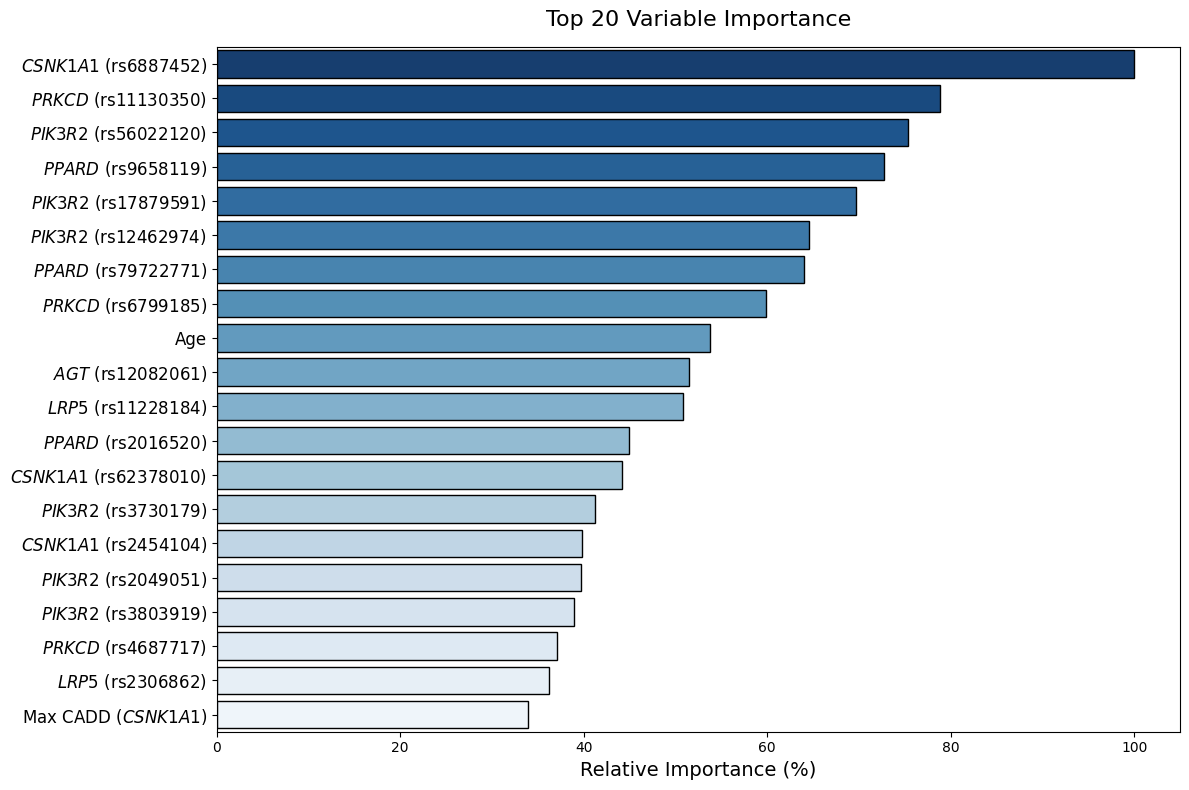

In [12]:
feature_importance = best_model_gbdt_withNA.feature_importances_
feature_names = df.drop("phenotype", axis=1).columns

top_importance = plot_feature_importance(feature_importance, feature_names, 20)
# plt.savefig("../plot/top_importance_withNA_PC.pdf")

Feautre Contributions

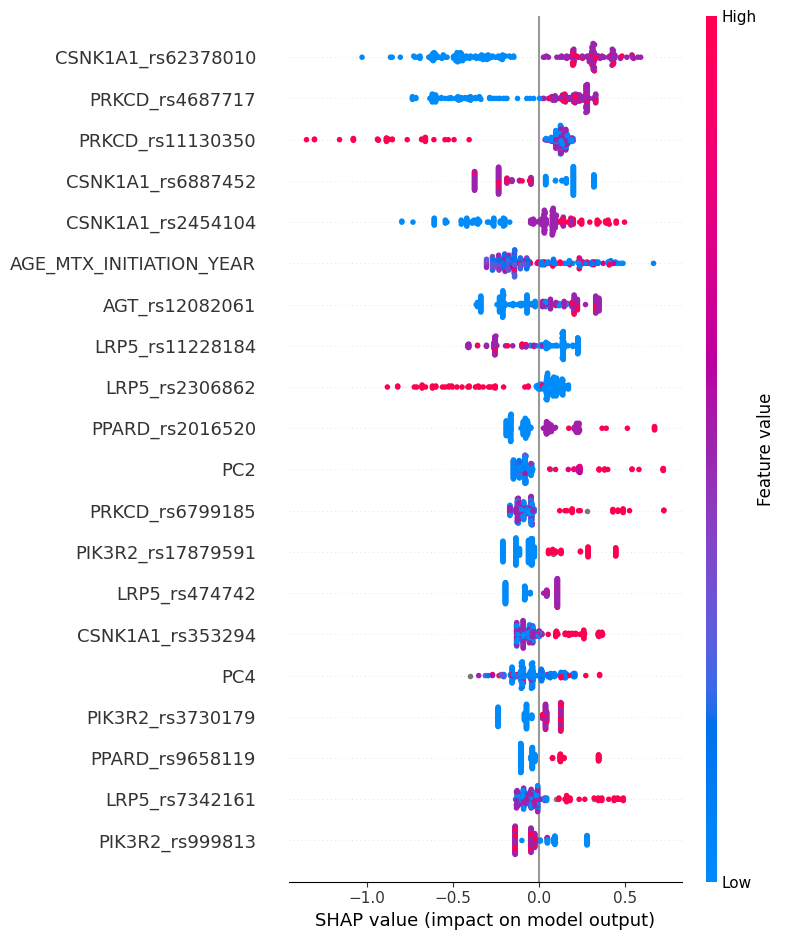

In [13]:
# Compute SHAP values
explainer = shap.Explainer(best_model_gbdt_withNA)
shap_values = explainer(X_train)
shap.summary_plot( shap_values.values, X_train, show=False, max_display=20)

In [ ]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

 
shap_importance = pd.DataFrame({
    "feature": X_train.columns,
    "mean_abs_shap": mean_abs_shap
})

# sort descending
shap_importance = shap_importance.sort_values("mean_abs_shap", ascending=False)
shap_importance[:20] 

,feature,mean_abs_shap
65,CSNK1A1_rs62378010,0.380777
180,PRKCD_rs4687717,0.297117
189,PRKCD_rs11130350,0.251663
24,CSNK1A1_rs6887452,0.220188
19,CSNK1A1_rs2454104,0.209417
262,AGE_MTX_INITIATION_YEAR,0.192602
118,AGT_rs12082061,0.192389
76,LRP5_rs11228184,0.177020
29,LRP5_rs2306862,0.155444
89,PPARD_rs2016520,0.138588


#### Performance Evaluation
* ROC-AUC curve plotting

In [14]:
def plot_roc_auc(y_true, y_pred_prob, save_path=None):
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=20)
    plt.ylabel('True Positive Rate', fontsize=20)
    plt.title('Receiver Operating Characteristic (ROC)',fontsize=20)
    plt.legend(loc='lower right', fontsize=16)
    
    if save_path:
        plt.savefig(save_path)
    
    plt.show()
    

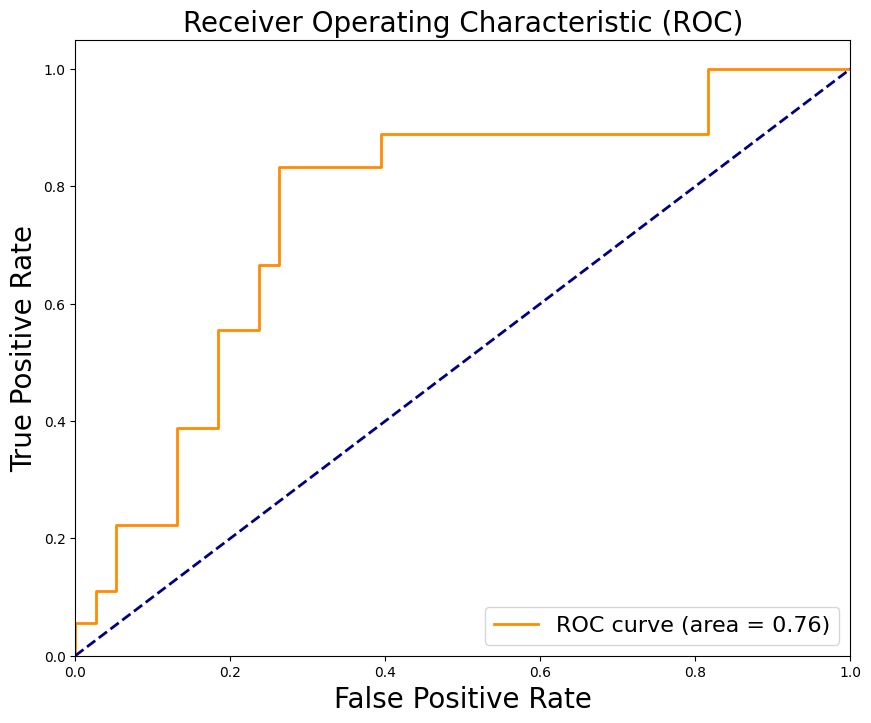

In [15]:

positive_prob = best_model_gbdt_withNA.predict_proba(X_test)[:,1]

plot_roc_auc(y_test, positive_prob)

#### Ablation Test (without genetic variants)

In [16]:
X_test_ablated = X_test.iloc[:,-7:]
X_train_ablated = X_train.iloc[:,-7:] 

In [17]:
grid_search.fit(X_train_ablated, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'alpha': [0], 'lambda': [1.5], 'learning_rate': [0.5], 'max_depth': [3], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [18]:
best_model_withNA_ablated_PC = grid_search.best_estimator_  

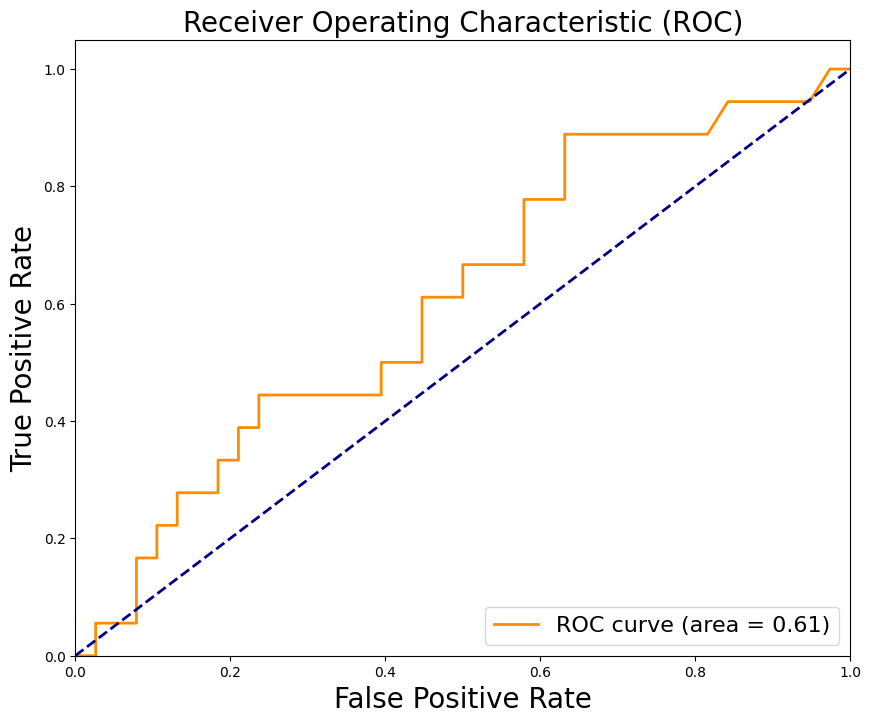

In [19]:
#Predict probabilityes of positive class of each instance
positive_prob = best_model_withNA_ablated_PC.predict_proba(X_test_ablated)[:,1]

plot_roc_auc(y_test, positive_prob)

##### Model without PCs

In [20]:
X_test_no_PC = X_test.iloc[:,:-5]
X_train_no_PC = X_train.iloc[:,:-5]

In [21]:
grid_search.fit(X_train_no_PC, y_train)
best_model_withNA_noPC = grid_search.best_estimator_

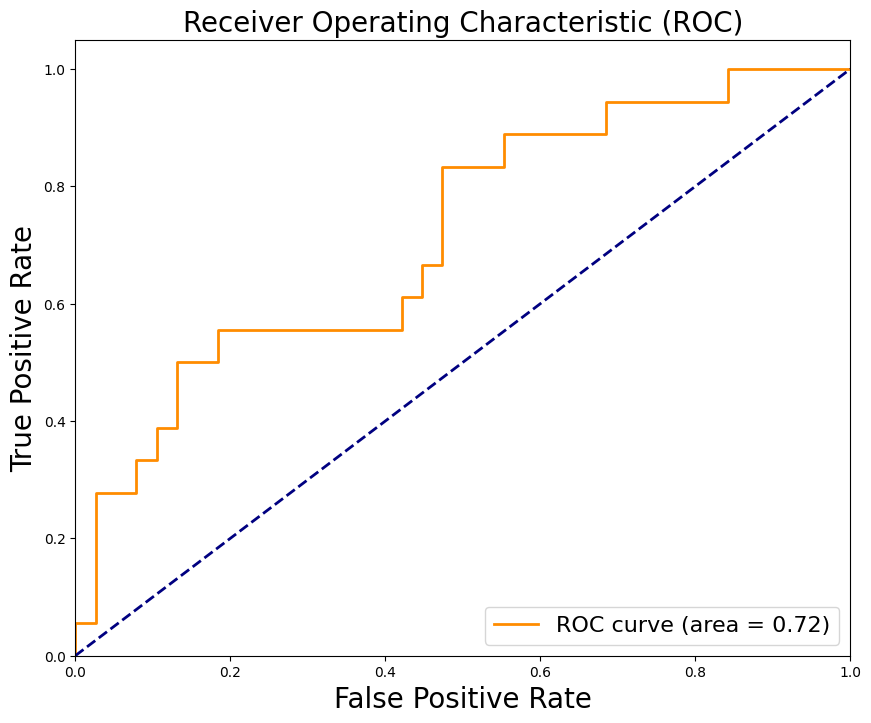

In [22]:
#Predict probabilityes of positive class of each instance
positive_prob = best_model_withNA_noPC.predict_proba(X_test_no_PC)[:,1]

plot_roc_auc(y_test, positive_prob)